# Fall 2025 - Assignment 1

Electronic submission on ZoneCours no later than **October 17 at 11:55 PM** of:

* This Jupyter notebook (.ipynb) as the report, after adding your answers.
* All .py files necessary to run the notebook

The report must:

* be in .ipynb format (points will be deducted for any other format).
* include the student ID number of all team members in the first cell (i.e., replace these instructions).
* answer the questions and discuss the results using tables, figures, and Markdown cells.

Grading rubric:

* **40%** Accuracy of results
* **25%** Complete and concise discussions (Markdown cells)
* **20%** Conciseness of the notebook (.ipynb with minimal code) and clarity of figures
* **15%** Code clarity (.py)

# Context

We are going to consider the most liquid options traded on Apple on two particular business days of 2020: January 17 and March 20. The next couple of code cells were used to generate the dataset by connecting to OptionMetrics. With `GENERATE = False`, they simply load the dataset as saved to disk.

In [2]:
# The following import allow absolute imports scripts within the dorion_francois package
# import internal_script 

import datetime as dt
import os
import sys
import numpy as np
import pandas as pd
import pickle
import importlib

In [3]:
def filters(options):
    """These filters were applied to the data"""
    # Options before maturity
    options = options.loc[options.date < options.exdate].reset_index()

    # Positive open interest
    options = options[options['open_interest'] > 0] 

    # Abs(delta) between 0.01 and 0.99
    options = options[(options['delta'].abs() >= 0.01) & (options['delta'].abs() <= 0.99)] 

    # Implied vol between 0.03 and 2
    options = options[(options['impl_volatility'] >= 0.03) & (options['impl_volatility'] <= 2)] 

    # Bid price is greater than 0.1 and less than ask price
    options = options[(options['best_offer'] > options['best_bid']) & (options['best_bid'] > 0.1)] 
    
    return options

GENERATE = False
if GENERATE:
    import dorion_francois.option_metrics as om    
    jan17 = om.get_option_data(101594, dt.date(2020,1,17))
    mar20 = om.get_option_data(101594, dt.date(2020,3,20))
    options = filters( pd.concat((jan17,mar20),axis=0) )
    with open('202510-assignment1.pkl','wb') as fh:
        # OptionMetrics 'strike_price' column is the strike x1000. We'll drop it to avoid confusion; use the 'strike' column
        pickle.dump(options.drop(columns=['strike_price']),fh)
else:
    with open('202510-assignment1.pkl','rb') as fh:
        options = pickle.load(fh)
options.describe()

,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,...,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
count,3041.000000,3041.0,3041.0,3041.0,3041.0,3041.0,3041.000000,3041.0,3041.0,3041.0,...,3041.0,3041.000000,3041.000000,3041.000000,3041.000000,3041.000000,3041.000000,3039.000000,2907.000000,3041.000000
mean,1290.575469,101594.0,39.54265,41.070812,302.719171,1493.480434,0.486984,0.051175,0.004216,43.996647,...,40.306731,247.602105,0.678362,0.011057,267.849300,266.408353,268.266957,0.491364,0.463369,0.517211
std,588.418749,0.0,47.505847,48.379765,1413.149222,2810.188475,0.246677,0.573104,0.00421,39.878651,...,47.939597,256.838994,0.703668,0.005106,44.329611,44.126488,45.364910,0.240483,0.227888,0.264064
min,166.000000,101594.0,0.11,0.14,0.0,1.0,0.209335,-0.989916,0.00004,0.264909,...,0.13,7.000000,0.019178,0.004597,229.240000,226.093746,227.456884,0.209760,0.004413,0.211192
25%,805.000000,101594.0,3.85,4.75,0.0,76.0,0.308580,-0.332122,0.001665,13.6014,...,4.25,35.000000,0.095890,0.006167,229.240000,227.603325,228.595023,0.313801,0.290405,0.324194
50%,1334.000000,101594.0,20.05,21.5,14.0,383.0,0.407585,0.02422,0.003027,29.80537,...,20.8,154.000000,0.421918,0.008564,229.240000,229.240000,229.774853,0.414581,0.389198,0.437239
75%,1800.000000,101594.0,60.75,63.0,97.0,1594.0,0.593389,0.526664,0.005168,64.20898,...,61.75,455.000000,1.246575,0.016588,318.730000,317.145554,319.221626,0.603811,0.573138,0.637671
max,2345.000000,101594.0,271.0,275.5,29443.0,28015.0,1.998797,0.989859,0.042843,193.543,...,273.25,882.000000,2.416438,0.017424,318.730000,318.730000,325.069560,1.656574,1.601841,2.527934


In [4]:
options.columns

Index(['index', 'secid', 'date', 'symbol', 'symbol_flag', 'exdate',
       'last_date', 'cp_flag', 'best_bid', 'best_offer', 'volume',
       'open_interest', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta',
       'optionid', 'cfadj', 'am_settlement', 'contract_size', 'ss_flag',
       'forward_price', 'expiry_indicator', 'root', 'suffix', 'hash', 'strike',
       'option_price', 'is_call', 'DTM', 'YTM', 'risk_free', 'stock_price',
       'stock_exdiv', 'implied_forward_price', 'implied_vol_bms',
       'implied_vol_bid', 'implied_vol_ask'],
      dtype='object')

In [13]:

pd.unique(options.stock_exdiv)

array([318.73      , 317.96094474, 317.14555371, 316.33363192,
       316.13148708, 315.71495178, 315.50057294, 315.28701947,
       314.85278349, 229.24      , 228.42106597, 227.60332472,
       227.39911132, 226.97637523, 226.75785899, 226.53955906,
       226.09374562])

# Question 1

Create a scatter plot with the risk-free rate (`100*options.risk_free`) against the time to maturity expressed in years (`options.YTM`). Discuss the figure. Given that the Black-Merton-Scholes economy assumes that the risk-free rate is constant, should one still account for the variation it illustrates if pricing options with the model? Why?

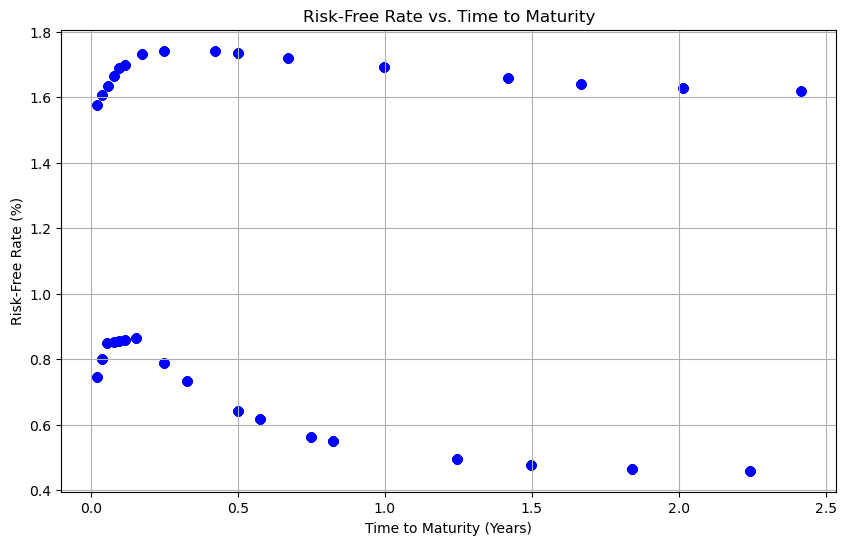

In [7]:
import matplotlib.pyplot as plt
# Assuming options.risk_free and options.YTM are defined
risk_free_rates = 100 * options.risk_free  # Convert to percentage
time_to_maturity = options.YTM  # Time to maturity in years

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(time_to_maturity, risk_free_rates, color='blue', alpha=0.7)
plt.title('Risk-Free Rate vs. Time to Maturity')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Risk-Free Rate (%)')
plt.grid(True)
plt.show()


From the above scatterplot, we see that the interest regimes has changed between the 2 dates, which are before and after the COVID started. As such, the assumption in the BSM that the risk free rate is constant is no longer appropriate. One should consider time varying risk free rate for the pricing.

# Question 2
Similarly, scatter `options.stock - options.stock_exdiv`, where the former is the stock price and the latter accounts for the dividends **actually** paid over the life of the options.

Discuss the figure. Can we conclude that Apple changed its dividend policy between the two dates? Describe which variation of the Black-Merton-Scholes formula seen in class could be used to price the options on Apple if they were European options. Support your discussion with succinct mathematical expressions and/or derivations, in which you can focus on the calls without loss of generality.

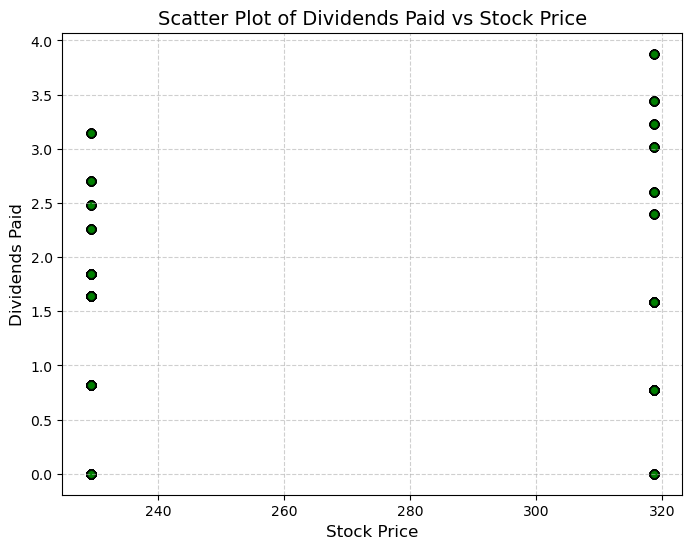

In [19]:
dividends_paid = options['stock_price'] - options['stock_exdiv']  # Dividends paid
stock_price = options['stock_price']  # Stock price

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(stock_price, dividends_paid, alpha=0.7, color='green', edgecolor='k')
plt.title('Scatter Plot of Dividends Paid vs Stock Price', fontsize=14)
plt.xlabel('Stock Price', fontsize=12)
plt.ylabel('Dividends Paid', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

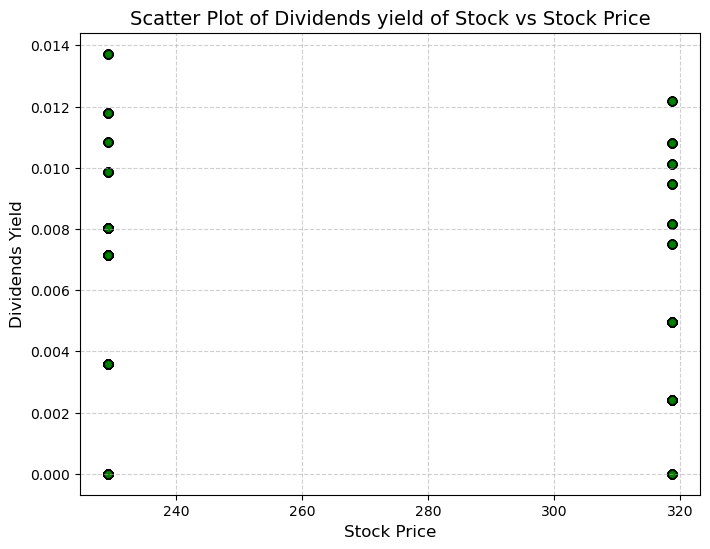

In [20]:
cts_div = (options['stock_price'] - options['stock_exdiv']) / options['stock_price']

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(stock_price, cts_div, alpha=0.7, color='green', edgecolor='k')
plt.title('Scatter Plot of Dividends yield of Stock vs Stock Price', fontsize=14)
plt.xlabel('Stock Price', fontsize=12)
plt.ylabel('Dividends Yield', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

From the figure, we can conclude that though the absolute dividend payout decreased after the COVID begins, taking into consideration of the stock price, it indeed increase the fraction of its dividend payout compare to the stock price. As such Apple changed its dividend policy between the 2 dates.\

Considering discrete dividend, we should directly considering the Black76 formula showed in the following slide and adjust forward price by the discrete dividend.

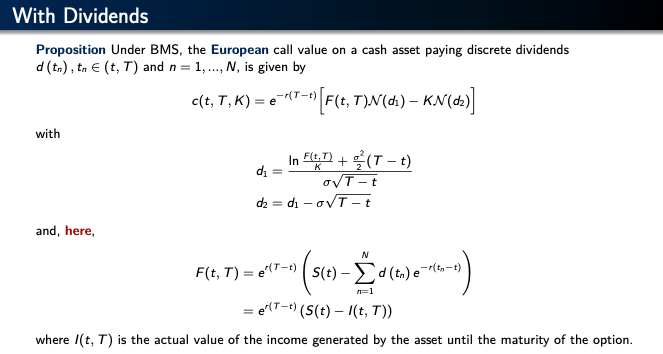

# Question 3
Implement a function that inverts this variation of the BSM formula to obtain the BMS implied volatility for each of the options in the dataframe. Define moneyness as $M = K / \hat{S}_t$ and focus on out-of-the-money (OTM) options ($M \le 1$ puts, $M > 1$ calls). Create a dataframe `otm_options` containing only those options and add a column with the result of your IV calculation for each option therein.

In a 1x2 figure, scatter your results, with  on the x-axis, against a line plot for `implied_vol_bms`: In the left (right) panel, use options quoted on Jan 17 and expiring on Feb 14 (July 17), 2020, and options quoted on Mar 20 expiring on April 17 (Oct. 16), 2020. On each panel, you should thus have 2 lines with your results scattered atop them. Discuss this figure: how does the level and span (across moneyness) of the smiles vary, compare across maturities, etc. Given your discussion, can you suggest a better measure for moneyness? If you generate anew the previous figure using this alternate moneyness measure, how does it impact your analysis of the figure?

In [29]:
otm_options_call = options[(options['strike'] / options['stock_exdiv'] > 1) & (options['cp_flag'] == 'C')]
otm_options_put = options[(options['strike'] / options['stock_exdiv'] <= 1) & (options['cp_flag'] == 'P')]
otm_options = pd.concat((otm_options_call, otm_options_put), axis=0)

,index,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,best_bid,best_offer,...,is_call,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
92,222,101594.0,2020-01-17,AAPL 200124C320000,1,2020-01-24,2020-01-17,C,3.05,3.1,...,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.209760,0.208328,0.211192
94,223,101594.0,2020-01-17,AAPL 200124C322500,1,2020-01-24,2020-01-17,C,2.11,2.16,...,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.211230,0.209694,0.212763
96,224,101594.0,2020-01-17,AAPL 200124C325000,1,2020-01-24,2020-01-17,C,1.43,1.47,...,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.214048,0.212644,0.215448
98,225,101594.0,2020-01-17,AAPL 200124C327500,1,2020-01-24,2020-01-17,C,0.98,1.0,...,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.219633,0.218793,0.220471
100,226,101594.0,2020-01-17,AAPL 200124C330000,1,2020-01-24,2020-01-17,C,0.68,0.71,...,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.228090,0.226540,0.229627


In [31]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import golden

def black76(option_type: str, T: float, K: float, S_hat: float, r: float, sigma: float) -> float:
    """Implementation of Black76 formula

    Args:
        option_type (str): Type of the option, i.e. 'C' or 'P'
        T (float): Time to maturity in years
        K (float): strike price
        S_hat (float): ex-div spot price
        r (float): risk free rate
        sigma (float): implied volatility

    Returns:
        float: option price
    """
    
    # calculate the forward
    F = np.exp(r * T) * S_hat
    d1 = (np.log(F / K) + (sigma ** 2) * T / 2) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "C":
        return np.exp(-1 * r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    elif option_type == "P":
        return np.exp(-1 * r * T) * (K * norm.cdf(-1 * d2) - F * norm.cdf(-1 * d1))
    else:
        raise ValueError("option_type takes only 'C' and 'P'")

def solve_imp_vol(option_type: str, option_price: float, T: float, K: float, S_hat: float, r: float) -> float:
    """Finding the implied volatility using Golden Section Search

    Args:
        option_type (str): Type of the option, i.e. 'C' or 'P'
        option_price (float): Market price of the option
        T (float): Time to maturity in years
        K (float): strike price
        S_hat (float): ex-div spot price
        r (float): risk free rate

    Returns:
        float: calibrated implied volatility
    """
    def objective_func(sigma):
        model_price = black76(option_type, T, K, S_hat, r, sigma)
        market_price = option_price
        return (model_price - market_price) ** 2
    
    sigma_hat = golden(objective_func, 
                       brack=(0.0, 10.0),  # interval
                       tol=1e-5,  # tolerance for stopping criterion
                        maxiter=1000,  # maximum number of iterations
                       )

    return sigma_hat


In [35]:
otm_options['self_calc_imp_vol'] = otm_options.apply(
    lambda row: solve_imp_vol(row['cp_flag'], row['option_price'], row['YTM'], row['strike'], row['stock_exdiv'], row['risk_free']),
    axis = 1
)

/var/folders/m6/qxrb85nn4t37j5wx5szgb8800000gn/T/ipykernel_51447/3947615973.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(F / K) + (sigma ** 2) * T / 2) / (sigma * np.sqrt(T))


In [48]:
type(otm_options.date.values[0])

datetime.date

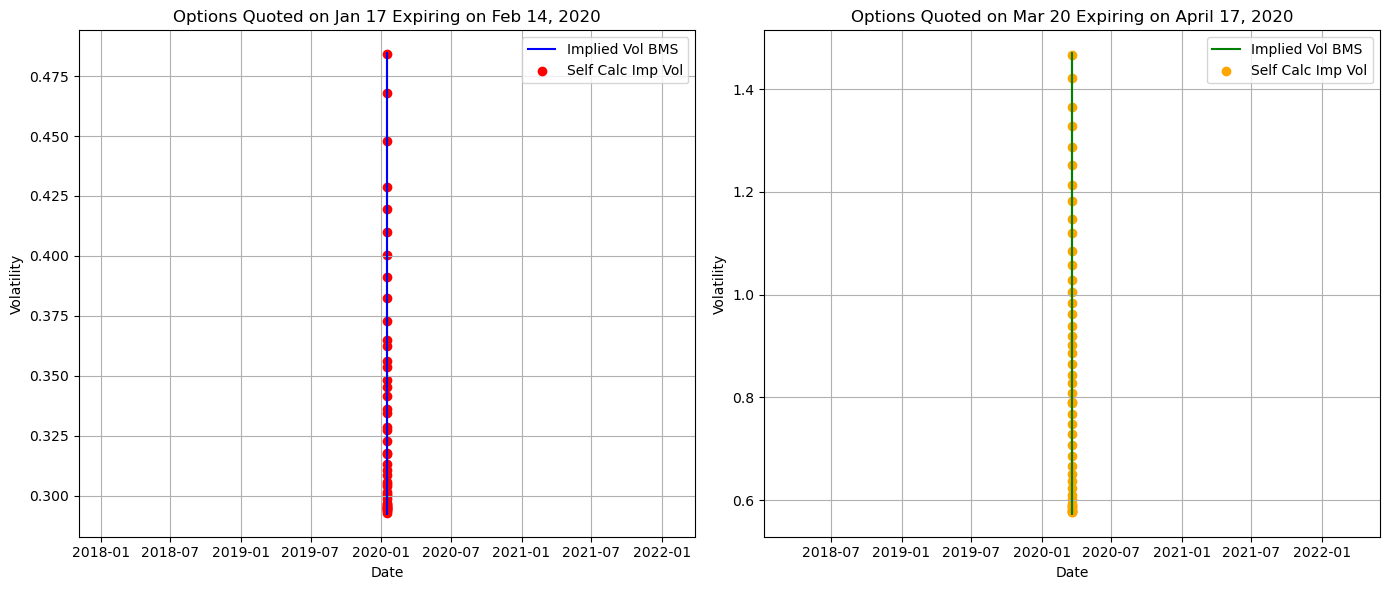

In [54]:
# Filter data for the first panel (Jan 17 - Feb 14, 2020)
panel1_data = otm_options[(otm_options['date'] == dt.date(2020, 1, 17)) & (otm_options['exdate'] == dt.date(2020, 2, 14))]

# Filter data for the second panel (Mar 20 - April 17, 2020)
panel2_data = otm_options[(otm_options['date'] == dt.date(2020, 3, 20)) & (otm_options['exdate'] == dt.date(2020, 4, 17))]

# Create a 1x2 figure
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left panel
axs[0].plot(panel1_data['date'], panel1_data['implied_vol_bms'], label='Implied Vol BMS', color='blue')
axs[0].scatter(panel1_data['date'], panel1_data['self_calc_imp_vol'], color='red', label='Self Calc Imp Vol')
axs[0].set_title('Options Quoted on Jan 17 Expiring on Feb 14, 2020')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Volatility')
axs[0].legend()
axs[0].grid()

# Right panel
axs[1].plot(panel2_data['date'], panel2_data['implied_vol_bms'], label='Implied Vol BMS', color='green')
axs[1].scatter(panel2_data['date'], panel2_data['self_calc_imp_vol'], color='orange', label='Self Calc Imp Vol')
axs[1].set_title('Options Quoted on Mar 20 Expiring on April 17, 2020')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Volatility')
axs[1].legend()
axs[1].grid()

# Show the plots
plt.tight_layout()
plt.show()


Better measure for moneyness should be $\frac{K}{F}$, here F is the forward price that matures at the same time as the option

In [55]:
otm_options.columns

Index(['index', 'secid', 'date', 'symbol', 'symbol_flag', 'exdate',
       'last_date', 'cp_flag', 'best_bid', 'best_offer', 'volume',
       'open_interest', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta',
       'optionid', 'cfadj', 'am_settlement', 'contract_size', 'ss_flag',
       'forward_price', 'expiry_indicator', 'root', 'suffix', 'hash', 'strike',
       'option_price', 'is_call', 'DTM', 'YTM', 'risk_free', 'stock_price',
       'stock_exdiv', 'implied_forward_price', 'implied_vol_bms',
       'implied_vol_bid', 'implied_vol_ask', 'self_calc_imp_vol'],
      dtype='object')

In [66]:
otm_options['forward_moneyess'] = otm_options['strike'] / otm_options['implied_forward_price']

# Question 4

Consider the same OTM options as in the previous question. We now want to scatter
\begin{equation}
    100 \left(\frac{ \text{'impl\_volatility'} }{ \text{'implied\_vol\_bms'} } - 1\right)
\end{equation}
against moneyness (the version you feel most comfortable with). The 'impl_volatility' column provides an implied volatility measure as computed by the data provider using a proprietary algorithm. How should the y-axis be interpreted? Are the magnitudes relatively large or small? Would we obtain the same result comparing CRR and BMS implied volatilities for the in-the-money (ITM) options?

In [58]:
otm_options['question 4 quantity'] = 100 * (otm_options['impl_volatility'] / otm_options['implied_vol_bms'] - 1)

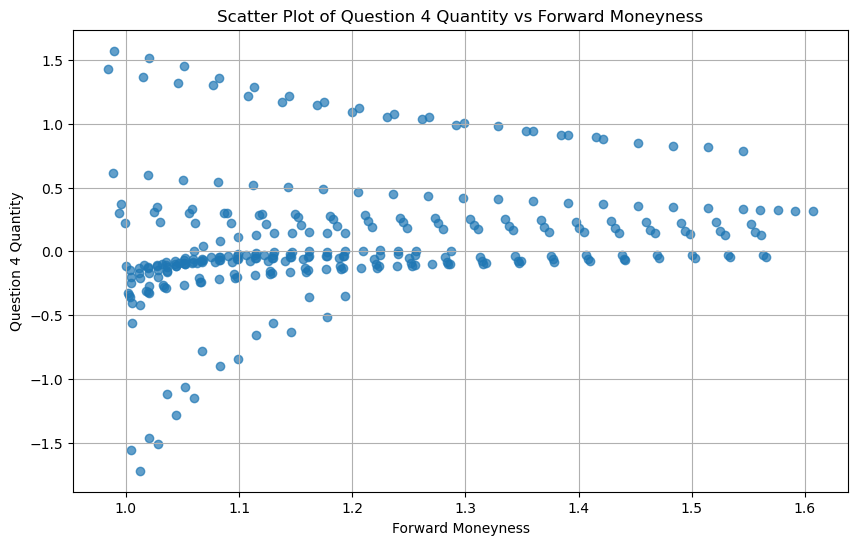

In [67]:
otm_options_jan_C = otm_options[(otm_options['date'] == dt.date(2020, 1, 17)) & (otm_options['cp_flag'] == 'C')]
otm_options_mar_C = otm_options[(otm_options['date'] == dt.date(2020, 3, 20)) & (otm_options['cp_flag'] == 'C')]
plt.figure(figsize=(10, 6))
plt.scatter(otm_options_jan_C['forward_moneyess'], otm_options_jan_C['question 4 quantity'], alpha=0.7)
plt.title('Scatter Plot of Question 4 Quantity vs Forward Moneyness')
plt.ylabel('Question 4 Quantity')
plt.xlabel('Forward Moneyness')
plt.grid()
plt.show()


We see that when we are close to ATM, the American option CRR tree calculated implied vol has a large distance to the BSM implied volatility. However, when the option goes deep OTM, the difference is smaller. The difference is caused by the early exercise option for the American option considered within the CRR tree. Following this logic, for ITM option, the quantity calculated will have a wilder divergence from 1.

# Question 5

Convert the present value of dividends corresponding to each option into an approximate convenience yield. Implement the CRR tree with diviended yield ($y$) and obtain your own CRR-implied volatility; use a number of time steps equal to 5 times the days to maturity ('DTM').  Compare it with the 'impl_volatility' provided in the dataframe. In particular, does this yield better approximations than the ones in 'implied_vol_bms'? Support your answer with some summary statistics and a figure.

In [68]:
import copy as cp
options_copy = cp.deepcopy(options)

In [69]:
options_copy['dividend_paid'] = options_copy['stock_price'] - options_copy['stock_exdiv']

$3.146254 = [(1 + d)^{2.25} - 1] * 229.24 = [\exp(2.25 * y) - 1] * 229.24$

In [ ]:
def calc_div_yield(YTM, dividends_paid, stock_price):
    """Calculate the continuous dividend yield

    Args:
        YTM (float): time to maturity in years
        dividends_paid (float): dividends paid
        stock_price (float): stock price

    Returns:
        float: continuous dividend yield
    """
    if dividends_paid <= 0:
        return 0.0
    else:
        return -1 * np.log(1 - dividends_paid / stock_price) / YTM

In [71]:
options_copy[['date', 'stock_price', 'exdate', 'dividend_paid']].tail()

,date,stock_price,exdate,dividend_paid
4080,2020-03-20,229.24,2022-06-17,3.146254
4082,2020-03-20,229.24,2022-06-17,3.146254
4083,2020-03-20,229.24,2022-06-17,3.146254
4084,2020-03-20,229.24,2022-06-17,3.146254
4085,2020-03-20,229.24,2022-06-17,3.146254


# Question 6

Given that the CRR tree should converge to the BMS model, the implied volatility obtained from American options prices using the CRR model can be used in the BMS closed-form formulas to obtain the price at which otherwise identical European options should be traded. Use the approximate convenience yield obtained in the previous question and the 'implied_vol_bms' field provided with the data to do so. 

Plot the resulting value of early exercise options. (Hint: Because we are using an approximate convenience yield, some of these values could make little economic sense. Use your economic intuition to impose an upper bound on the artifical European prices.) Discuss the observed patterns.

# Question 7

Muravyev, Pearson and Pollet (2022), suggest that we can use put-call parity to infer borrow fees on stocks. Let $h_t$ be the borrow fee at time $t$. An investor who buy the stock at $S_t$ can lend the stock and receive $h_tS_t$ at time $t+1$.

We can estimate the implied borrow fee from the option prices under Q measure: $h_{t}^{\mathbb{Q}}$. The put-call parity relation including one-day borrow fee is
\begin{equation*}
\hat{S}_t - S_t \left(1 - (1 - e^{-r(T-t)} h_{t}^{\mathbb{Q}})^D \right) = c_t - p_t + e^{-r(T-t)}K
\end{equation*}
where $D$ is the number of days to maturity. Consequently, the one-day borrow fee is:
\begin{equation*}
h_{t}^{\mathbb{Q}} = e^{r(T-t)} \left[1 - \left(1 - \frac{1}{S_t} (\hat{S}_t - c_t + p_t - e^{-r(T-t)} K) \right)^{1/D} \right]
\end{equation*}

Unfortunately, whereas put-call parity applies only to European options, options on individual equities are typically American. However, Muravyev, Pearson and Pollet (2025) suggest that, using a CRR implied volatility for American options, one can use the difference in 1-month ATM implied volatility of puts and calls in to compute an approximation to the above, which is
\begin{equation*}
h_t^{\mathbb{Q}} \approx -(\sigma_c - \sigma_p) / \sqrt{2\pi (T-t)}.
\end{equation*}
Compute this approximation on both dates in the sample and discuss your results.